# Model Training Script
Lindsay Fitzpatrick
ljob@umich.edu
12/18/2024

This script reads in CFSR data from 1979 - 2010 and trains machine learning models to target CNBS from L2SWBM across the 5 Great Lakes simultaeously.

In [1]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.ensemble import RandomForestClassifier as skRFC
from sklearn.gaussian_process.kernels import WhiteKernel, ConstantKernel, RBF, Matern, RationalQuadratic, ExpSineSquared
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor as skRFR
from sklearn.linear_model import LinearRegression as skLR
import tensorflow as tf
import joblib
import numpy as np
from sklearn.metrics import mean_squared_error, r2_score
from properscoring import crps_ensemble
import sqlite3
import sys
import os

In [2]:
# Add the path to the src directory (two levels up)
sys.path.append(os.path.abspath('../../../'))
from src.data_processing import shift_variables
from src.data_loader import load_glcc_data, load_l2swbm_data

## User Input

In [3]:
# This is the directory where you cloned the repo
local_path = '/Users/ljob/Desktop/'

dir = local_path + 'cnbs-predictor/data/'

## Begin Script

In [4]:
## Read in PCP data from CFSR [mm]
pcp_data = pd.read_csv(dir+'training/CFSR_APCP_Basin_Avgs.csv',sep=',')

## Read in EVAP data from CFSR [mm]
evap_data = pd.read_csv(dir+'training/CFSR_EVAP_Basin_Avgs.csv',sep=',')

## Read in TMP data from CFSR [K]
tmp_data = pd.read_csv(dir+'training/CFSR_TMP_Basin_Avgs.csv',sep=',')

In [5]:
# Features
X = pd.DataFrame({
    'superior_lake_precipitation':  pcp_data['sup_lake'],
    'michigan-huron_lake_precipitation': pcp_data['mih_lake'],
    'erie_lake_precipitation': pcp_data['eri_lake'],
    'ontario_lake_precipitation': pcp_data['ont_lake'],
    'superior_land_precipitation': pcp_data['sup_land'],
    'michigan-huron_land_precipitation': pcp_data['mih_land'],
    'erie_land_precipitation': pcp_data['eri_land'],
    'ontario_land_precipitation': pcp_data['ont_land'],
    'superior_lake_evaporation': evap_data['sup_lake'],
    'michigan-huron_lake_evaporation': evap_data['mih_lake'],
    'erie_lake_evaporation': evap_data['eri_lake'],
    'ontario_lake_evaporation': evap_data['ont_lake'],
    'superior_land_evaporation': evap_data['sup_land'],
    'michigan-huron_land_evaporation': evap_data['mih_land'],
    'erie_land_evaporation': evap_data['eri_land'],
    'ontario_land_evaporation': evap_data['ont_land'],
    'superior_lake_air_temperature': tmp_data['sup_lake'],
    'michigan-huron_lake_air_temperature': tmp_data['mih_lake'],
    'erie_lake_air_temperature': tmp_data['eri_lake'],
    'ontario_lake_air_temperature': tmp_data['ont_lake'],
    'superior_land_air_temperature': tmp_data['sup_land'],
    'michigan-huron_land_air_temperature': tmp_data['mih_land'],
    'erie_land_air_temperature': tmp_data['eri_land'],
    'ontario_land_air_temperature': tmp_data['ont_land']
})

# Set the index by date
X.set_index(pd.to_datetime(pcp_data[['year', 'month']].assign(day=1)), inplace=True)

In [6]:
X_shifted = shift_variables(X, lag=0, lead=10)

In [7]:
#Add a month variable to the shifted DataFrame
X_shifted = pd.concat([X_shifted, pd.DataFrame({'month': X_shifted.index.month,}, index=X_shifted.index)], axis=1)
X_shifted = pd.get_dummies(X_shifted, columns=['month'], prefix='month')

In [8]:
feature_column_order = (
    [f'month_{i}' for i in range(1, 13)] +
    [
        f'{lake}_{surface_type}_{comp}_mo{m}'
        for lake in ['superior', 'michigan-huron', 'erie', 'ontario']
        for surface_type in ['lake', 'land']
        for comp in ['precipitation', 'evaporation', 'air_temperature']
        for m in range(10) #from 0 to 9, representing the 10 months of lead time
    ]
)

In [9]:
X_reorg = X_shifted.reindex(columns=feature_column_order)
print(X_reorg)

            month_1  month_2  month_3  month_4  month_5  month_6  month_7  \
1979-01-01     True    False    False    False    False    False    False   
1979-02-01    False     True    False    False    False    False    False   
1979-03-01    False    False     True    False    False    False    False   
1979-04-01    False    False    False     True    False    False    False   
1979-05-01    False    False    False    False     True    False    False   
...             ...      ...      ...      ...      ...      ...      ...   
2009-11-01    False    False    False    False    False    False    False   
2009-12-01    False    False    False    False    False    False    False   
2010-01-01     True    False    False    False    False    False    False   
2010-02-01    False     True    False    False    False    False    False   
2010-03-01    False    False     True    False    False    False    False   

            month_8  month_9  month_10  ...  ontario_land_air_temperature_m

In [10]:
# Path to GLSEA SST data
sst_path = dir + 'glsea/glsea_sst_1995-2024.csv'

df_sst = pd.read_csv(sst_path, sep=r'\s+', skiprows=6, comment='-')

# Convert Year + Day-of-year to datetime
df_sst['date'] = pd.to_datetime(df_sst['Year'].astype(str) + df_sst['Day'].astype(str), format='%Y%j')

# Set date as index and drop Year/Day columns
df_sst.set_index('date', inplace=True)
df_sst.drop(columns=['Year', 'Day'], inplace=True)

# Rename columns
df_sst.columns = ['superior_sst', 'michigan_sst', 'huron_sst', 'erie_sst', 'ontario_sst', 'stclair_sst']

#Calculate Michigan-Huron average
df_sst['michigan-huron_sst'] = (df_sst['michigan_sst'] + df_sst['huron_sst']) / 2

#Convert SST from Celsius to Kelvin to be consistent with other data
df_sst_k = df_sst + 273.15

df_sst_k = df_sst_k.reindex(columns=['superior_sst', 'michigan-huron_sst', 'erie_sst', 'ontario_sst'])

print(df_sst_k.head())

            superior_sst  michigan-huron_sst  erie_sst  ontario_sst
date                                                               
1995-01-01        276.44             277.910    277.85       277.23
1995-01-02        276.43             277.850    277.79       277.20
1995-01-03        276.42             277.770    277.73       277.17
1995-01-04        276.42             277.700    277.66       277.14
1995-01-05        276.37             277.555    277.43       277.12


In [11]:
X_merged = pd.merge(df_sst_k, X_reorg, left_index=True, right_index=True, how='inner')
print(X_merged)

            superior_sst  michigan-huron_sst  erie_sst  ontario_sst  month_1  \
1995-01-01        276.44             277.910    277.85       277.23     True   
1995-02-01        274.67             274.975    273.35       276.25    False   
1995-03-01        273.68             274.055    273.35       274.59    False   
1995-04-01        273.74             274.375    274.83       274.74    False   
1995-05-01        274.62             276.140    279.24       277.36    False   
...                  ...                 ...       ...          ...      ...   
2009-11-01        280.61             282.600    285.14       283.55    False   
2009-12-01        277.41             280.650    282.36       281.45    False   
2010-01-01        275.68             276.055    275.59       276.91     True   
2010-02-01        274.30             274.255    273.35       274.67    False   
2010-03-01        274.19             274.180    273.35       274.68    False   

            month_2  month_3  month_4  

Read in L2SWBM in [mm]

https://zenodo.org/records/13883098

In [12]:
l2 = load_l2swbm_data(dir + 'l2swbm/')

In [13]:
print(l2)

            superior_evap_obs  superior_runoff_obs  superior_precip_obs  \
date                                                                      
1950-01-01         125.357918                 33.2                88.75   
1950-02-01          70.413371                 25.5                36.98   
1950-03-01          42.505142                 31.0                62.08   
1950-04-01          25.310708                 48.1                89.29   
1950-05-01          -8.965747                115.5               147.60   
...                       ...                  ...                  ...   
2022-08-01           5.267900                 36.0                73.93   
2022-09-01          50.655000                 36.5               104.23   
2022-10-01          81.158000                 41.3                63.07   
2022-11-01          95.479000                 53.3               135.73   
2022-12-01         124.970000                 38.0                79.78   

            michigan-hur

In [14]:
glcc = load_glcc_data(dir + 'glcc/', units='mm')
# Step 1: Convert year_month to datetime
#glcc['year_month'] = pd.to_datetime(glcc['year_month'])

# Step 2: Filter between two dates
#start_date = '1950-01-01'
#end_date = '2022-12-01'
#glcc_filtered = glcc[(glcc['year_month'] >= start_date) & (glcc['year_month'] <= end_date)]

print(glcc)

            superior_nbs_obs  michigan-huron_nbs_obs  erie_nbs_obs  \
date                                                                 
1900-01-01        -17.790166               -3.899753    -21.604197   
1900-02-01         35.845198               93.342481    230.258928   
1900-03-01         -2.736949               42.680633    348.547715   
1900-04-01        110.581553              141.942632    196.528504   
1900-05-01        126.925992              106.593256     93.618188   
...                      ...                     ...           ...   
2024-10-01        -39.001518              -81.028207   -273.653165   
2024-11-01         38.405569               13.628170    -82.235331   
2024-12-01        -16.763810               25.348396    181.475257   
2025-01-01        -26.001012              -16.032319    -14.402798   
2025-02-01        -14.214475               24.656504     61.142201   

            ontario_nbs_obs  
date                         
1900-01-01       132.464197  

Here we prepare the data for training and testing. We set the features 'X' as total over lake
precipitation, total over lake evaporation, and the average air temperature over each lake. The
targets 'y' are RNBS for each lake simultaeously.

In [ ]:
# Targets are the components (P, E, R) fro L2SWBM and NBS from GLCC
targets = pd.DataFrame({
    'superior_target_evaporation': l2['superior_evap_obs'],
    'superior_target_precipitation': l2['superior_precip_obs'],
    'superior_target_runoff': l2['superior_runoff_obs'],
    'superior_target_nbs': glcc['superior_nbs_obs'],
    'michigan-huron_target_evaporation': l2['michigan-huron_evap_obs'],
    'michigan-huron_target_precipitation': l2['michigan-huron_precip_obs'],
    'michigan-huron_target_runoff': l2['michigan-huron_runoff_obs'],
    'michigan-huron_target_nbs': glcc['michigan-huron_nbs_obs'],
    'erie_target_evaporation': l2['erie_evap_obs'],
    'erie_target_precipitation': l2['erie_precip_obs'],
    'erie_target_runoff': l2['erie_runoff_obs'],
    'erie_target_nbs': glcc['erie_nbs_obs'],
    'ontario_target_evaporation': l2['ontario_evap_obs'],
    'ontario_target_precipitation': l2['ontario_precip_obs'],
    'ontario_target_runoff': l2['ontario_runoff_obs'],
    'ontario_target_nbs': glcc['ontario_nbs_obs']
})

# The dataframes are merged by date so we need to drop rows with NaN values
# This ensures that we only keep rows where all target values are available
targets = targets.dropna()

            superior_target_evaporation  superior_target_precipitation  \
date                                                                     
1950-01-01                   125.357918                          88.75   
1950-02-01                    70.413371                          36.98   
1950-03-01                    42.505142                          62.08   
1950-04-01                    25.310708                          89.29   
1950-05-01                    -8.965747                         147.60   
...                                 ...                            ...   
2022-08-01                     5.267900                          73.93   
2022-09-01                    50.655000                         104.23   
2022-10-01                    81.158000                          63.07   
2022-11-01                    95.479000                         135.73   
2022-12-01                   124.970000                          79.78   

            superior_target_runoff  s

In [25]:
targets_lead = shift_variables(targets, lag=0, lead=12)

In [36]:
target_column_order =[
        f'{lake}_target_{comp}_mo{m}'
        for lake in ['superior', 'michigan-huron', 'erie', 'ontario']
        for comp in ['precipitation', 'evaporation', 'runoff', 'nbs']
        for m in range(12) #from 0 to 11, representing the 12 month forecast
        ]


In [37]:
targets_reorg = targets_lead.reindex(columns=target_column_order)

In [38]:
print(targets_reorg)

            superior_target_precipitation_mo0  \
date                                            
1950-01-01                              88.75   
1950-02-01                              36.98   
1950-03-01                              62.08   
1950-04-01                              89.29   
1950-05-01                             147.60   
...                                       ...   
2021-09-01                              79.10   
2021-10-01                              38.14   
2021-11-01                              53.45   
2021-12-01                              97.16   
2022-01-01                              57.72   

            superior_target_precipitation_mo1  \
date                                            
1950-01-01                              36.98   
1950-02-01                              62.08   
1950-03-01                              89.29   
1950-04-01                             147.60   
1950-05-01                             127.64   
...                

In [39]:
# Make sure the features and target indices/dates align
# Make sure the features and target indices/dates align
aligned_y = targets_reorg.loc[X_reorg.index]

print(f'Number of Features: {X_reorg.shape[1]}')
print(f'Number of Targets: {aligned_y.shape[1]}')

Number of Features: 252
Number of Targets: 192


Split the data into training and testing data sets. We could do it as a random 80/20 split
but instead we set split the data set by date ranges. This can easily be adjusted.

In [40]:
# Split dataset by date ranges into training and testing sets
train_start_date = '1979-01-01'
train_end_date = '2004-12-01'
# Testing dataset
val_start_date = '2005-01-01'
val_end_date = '2011-01-01'


X_train = X_reorg[train_start_date:train_end_date]
y_train = aligned_y[train_start_date:train_end_date]
X_test = X_reorg[val_start_date:val_end_date]
y_test = aligned_y[val_start_date:val_end_date]

It is best practice to standardize the data from 0-1 before training

In [41]:
# Standardize the data
x_scaler = StandardScaler()
y_scaler = StandardScaler()
X_train_scaled = x_scaler.fit_transform(X_train)
X_test_scaled = x_scaler.transform(X_test)
y_train_scaled = y_scaler.fit_transform(y_train)
y_test_scaled = y_scaler.transform(y_test)

joblib.dump(x_scaler, 'x_scaler.joblib')
joblib.dump(y_scaler, 'y_scaler.joblib')

['y_scaler.joblib']

Training

Below we train different models using the same data and calculate the r squared values on the 
test data to compare performance.

In [42]:
# Testing Different Kernels
# Basic kernel using ConstantKernel:
#kernel = ConstantKernel(1.0, (1e-3, 1e3)) * RBF(1.0, (1e-2, 1e2))

# Matt's optimal kernel: 
kernel = 1.0 * Matern(nu=1.5) * RationalQuadratic()

# Test to add a seasonality component:
#period = 3.0  # Period of the season
#kernel = ConstantKernel(1.0, (1e-3, 1e3)) * RBF(length_scale=1.0, length_scale_bounds=(1e-2, 1e2)) + ExpSineSquared(length_scale=1.0, periodicity=period, periodicity_bounds=(1e-2, 1e2))

#kernel = 1.0 * ExpSineSquared(periodicity=12)

#kernel = 1.0 * RBF() + 1.0 * Matern(nu=2.5) + 1.0 * RationalQuadratic()

# Set up the model
gpr = GaussianProcessRegressor(kernel=kernel, alpha=0.1, n_restarts_optimizer=10, random_state=42)

# Fit the model
gpr.fit(X_train_scaled, y_train_scaled)

# Save the trained model
joblib.dump(gpr, 'GP_trained_model_12.joblib')

# Predictions
y_pred_GP, sigma = gpr.predict(X_test_scaled, return_std=True)

print(r2_score(y_test_scaled, y_pred_GP))

0.7622504445228285


/opt/anaconda3/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


In [44]:
## Linear Regression ##

# Initialize Linear Regression
lr_model = skLR()

# Train the model
trained_LR = lr_model.fit(X_train_scaled, y_train_scaled)

# Save the trained model
joblib.dump(trained_LR, 'LR_trained_model_12.joblib')

# Predict on the test set
y_pred_LR = trained_LR.predict(X_test_scaled)

print(r2_score(y_test_scaled, y_pred_LR))

-0.3932459087243447


In [45]:
## Random Forest Regressor Model:

# Initialize RandomForestRegressor
rfr_model = skRFR(random_state=42)

# Train the model
trained_RFR = rfr_model.fit(X_train_scaled, y_train_scaled)

# Save the trained model
joblib.dump(trained_RFR, 'RF_trained_model_12.joblib')

# Predict on the test set
y_pred_RFR = trained_RFR.predict(X_test_scaled)

print(r2_score(y_test_scaled, y_pred_RFR))

0.5267433399173234


Epoch 1/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.1152 - mae: 0.8519 - val_loss: 0.9719 - val_mae: 0.8058
Epoch 2/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.9445 - mae: 0.7887 - val_loss: 0.8885 - val_mae: 0.7643
Epoch 3/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.8458 - mae: 0.7376 - val_loss: 0.7831 - val_mae: 0.7045
Epoch 4/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.7375 - mae: 0.6748 - val_loss: 0.6690 - val_mae: 0.6371
Epoch 5/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.6322 - mae: 0.6104 - val_loss: 0.5817 - val_mae: 0.5855
Epoch 6/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.5425 - mae: 0.5587 - val_loss: 0.5330 - val_mae: 0.5557
Epoch 7/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.4918 - mae: 0.5276 - val_loss: 0.5077 - val_mae: 0.5394
Epoch 8/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.4628 - mae: 0.5116 - val_loss: 0.4885 - val_mae: 0.5268
Epoch 9/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.4486 - mae: 0.4998 - val_loss

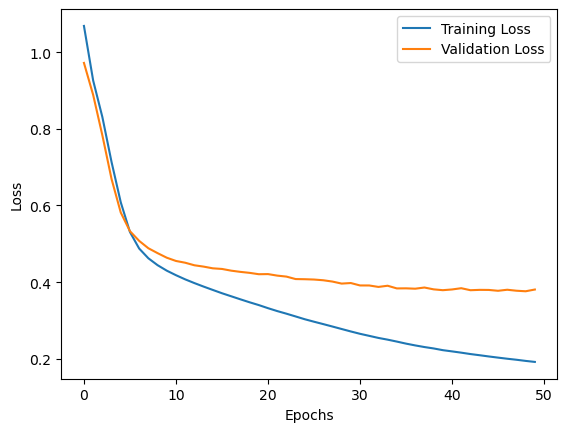

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
0.6008436952056976


In [46]:
## Neural Network ##

# Define the neural network architecture
nn_model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(X_train.shape[1],)),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(y_train.shape[1])
])

# Compile the model
nn_model.compile(optimizer='adam', loss='mse', metrics=['mae']) # Using mean squared error (mse) as the loss function

# Fit the model to the training data
history = nn_model.fit(X_train_scaled, y_train_scaled, epochs=50, batch_size=32, validation_split=0.2, verbose=1)#, callbacks=[early_stopping])

# Plotting the training and validation loss
import matplotlib.pyplot as plt

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

# Save the trained model
joblib.dump(nn_model, 'NN_trained_model_12.joblib')

# Predict on the test set
y_pred_NN = nn_model.predict(X_test_scaled)

print(r2_score(y_test_scaled, y_pred_NN))

Calculate Skill Metrics on the Test Data Set

In [ ]:
def compute_skill_metrics(model, y_true_std, y_pred_std, y_scaler):
    """
    Compute skill metrics from original and standardized predictions.

    Parameters:
        model (str): Model name.
        y_true (np.ndarray): True values (original scale).
        y_pred (np.ndarray): Predicted values (original scale).
        y_true_std (np.ndarray): Standardized true values.
        y_pred_std (np.ndarray): Standardized predicted values.

    Returns:
        pd.DataFrame: One-row DataFrame with metrics.
    """
    y_true = y_scaler.inverse_transform(y_true_std)
    y_pred = y_scaler.inverse_transform(y_pred_std)

    # Flatten in case of multidimensional input
    y_true = y_true.flatten()
    y_pred = y_pred.flatten()
    y_true_std = y_true_std#.flatten()
    y_pred_std = y_pred_std#.flatten()

    print(y_true_std, y_true_std.flatten())
    
    # Metrics
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true_std, y_pred_std)
    bias = np.mean(y_pred - y_true)
    std_dev = np.std(y_pred - y_true, ddof=1)  # unbiased estimate
    crps = np.mean(crps_ensemble(y_true, y_pred[:, None]))  # deterministic CRPS

    return pd.DataFrame([{
        'Model': model,
        'RMSE': round(rmse, 3),
        'R²': round(r2, 3),
        'Bias': round(bias, 3),
        'Std Dev': round(std_dev, 3),
        'CRPS': round(crps, 3)
    }])

In [ ]:
skill_GP = compute_skill_metrics('Gaussian Process', y_test_scaled, y_pred_GP, y_scaler)
skill_RF = compute_skill_metrics('Random Forest', y_test_scaled, y_pred_RFR, y_scaler)
skill_LR = compute_skill_metrics('Linear Regression', y_test_scaled, y_pred_LR, y_scaler)
skill_NN = compute_skill_metrics('Neural Network', y_test_scaled, y_pred_NN, y_scaler)

print(skill_GP)
results_df = pd.concat([skill_GP, skill_RF, skill_LR, skill_NN])

[[-0.42658253 -0.8980562  -1.21372613 ... -0.09703682  0.7543927
   0.04460792]
 [-0.89825544 -1.21637375 -1.27369506 ...  0.75360438  0.04710168
   1.13656864]
 [-1.21659178 -1.2764013   0.02883012 ...  0.04632657  1.14005435
   0.5104477 ]
 ...
 [-0.97509525 -1.46814647 -1.6509853  ...  0.15915359 -0.21599018
   0.11475553]
 [-1.46837936 -1.65406038 -1.528306   ... -0.21676037  0.11731301
  -1.04557502]
 [-1.65430425 -1.53126115 -1.12188799 ...  0.11653659 -1.0440716
  -0.42839046]] [-0.42658253 -0.8980562  -1.21372613 ...  0.11653659 -1.0440716
 -0.42839046]
[[-0.42658253 -0.8980562  -1.21372613 ... -0.09703682  0.7543927
   0.04460792]
 [-0.89825544 -1.21637375 -1.27369506 ...  0.75360438  0.04710168
   1.13656864]
 [-1.21659178 -1.2764013   0.02883012 ...  0.04632657  1.14005435
   0.5104477 ]
 ...
 [-0.97509525 -1.46814647 -1.6509853  ...  0.15915359 -0.21599018
   0.11475553]
 [-1.46837936 -1.65406038 -1.528306   ... -0.21676037  0.11731301
  -1.04557502]
 [-1.65430425 -1.531261

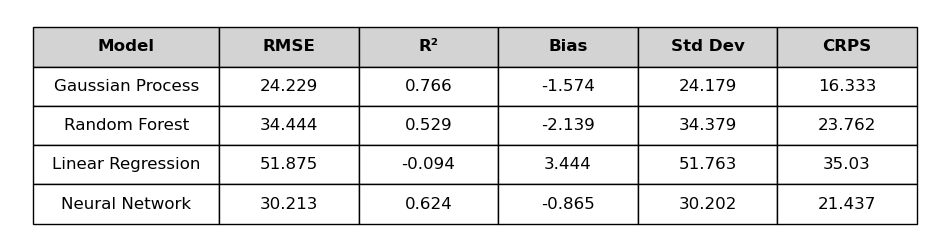

In [ ]:
def plot_styled_table(df):
    fig, ax = plt.subplots(figsize=(12, 3))
    ax.axis('off')  # Hide axes

    # Prepare table data: header + data
    table_data = [df.columns.to_list()] + df.round(3).values.tolist()

    # Create table
    table = ax.table(
        cellText=table_data,
        loc='center',
        cellLoc='center',
        edges='closed'
    )

    # Style header cells
    for (row, col), cell in table.get_celld().items():
        # Header row
        if row == 0:
            cell.set_facecolor('#d3d3d3')  # Grey background
            cell.get_text().set_fontweight('bold')
        cell.get_text().set_fontsize(12)

    # Adjust column widths and row heights
    for (row, col), cell in table.get_celld().items():
        # Increase height for all cells
        cell.set_height(0.17) 
        
        # Make 'Model' column wider
        if col == 0:
            cell.set_width(0.2)  # wider than default (~0.1)
        else:
            cell.set_width(0.15)  # default width for other columns

    # Prevent auto scaling messing with your manual sizes
    table.auto_set_font_size(False)

    plt.show()

plot_styled_table(results_df)

NameError: name 'models_info' is not defined

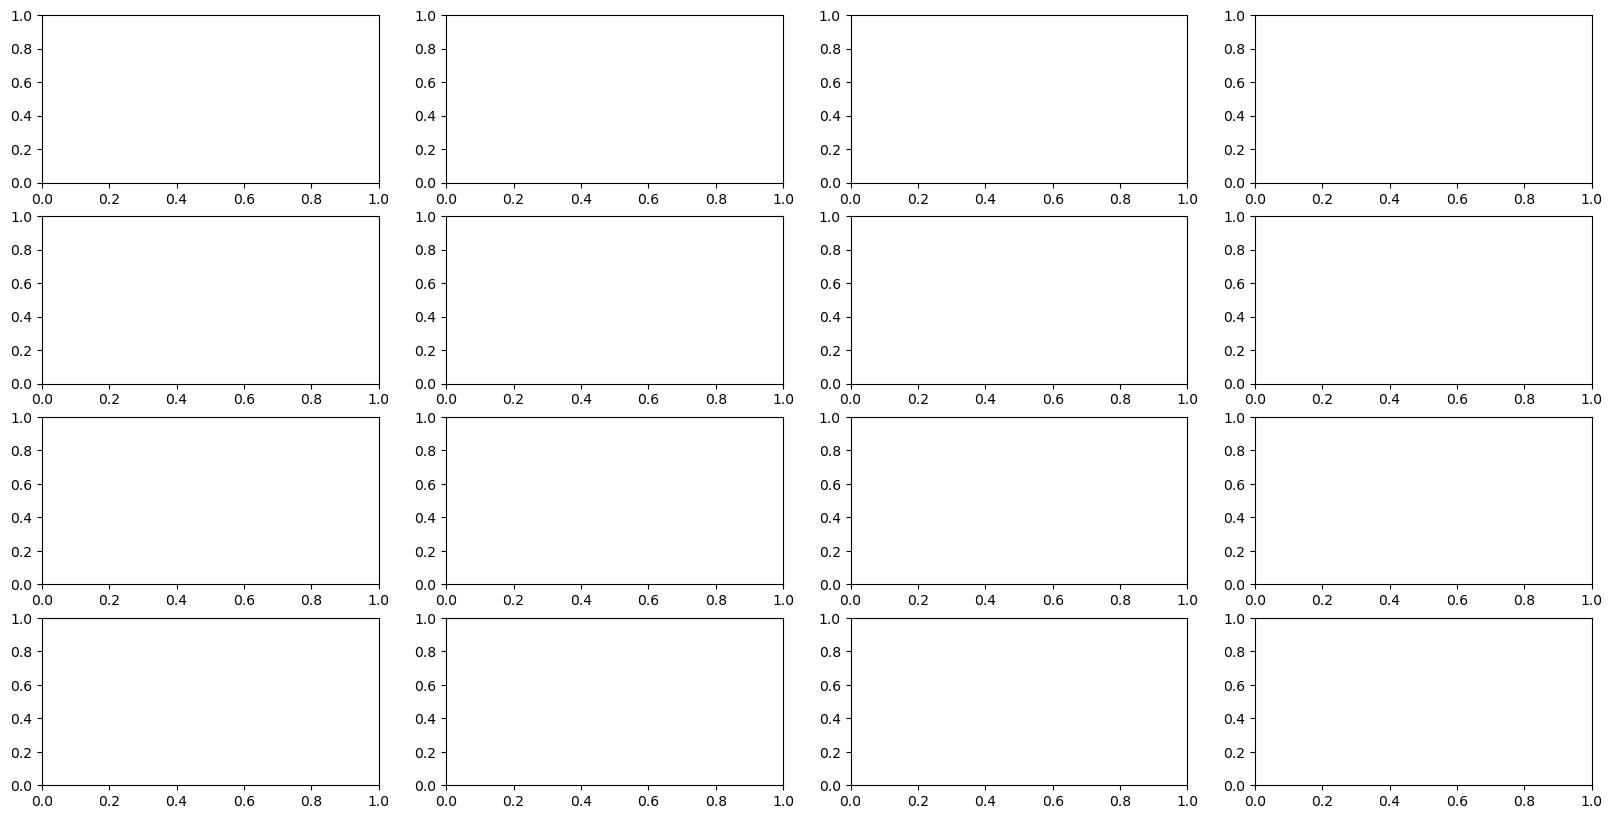

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
import pandas as pd

# Define model colors
model_colors = {'GP': 'blue', 'RF': 'green', 'LR': 'red', 'NN': 'purple'}

# Define lake names and components
lakes = ['superior', 'michigan-huron', 'erie', 'ontario']
components = ['precipitation', 'evaporation', 'runoff', 'cnbs']
titles = ['Precipitation', 'Evaporation', 'Runoff', 'CNBS']
ylabels = ['Superior', 'Mich-Huron', 'Erie', 'Ontario']

# Create subplot grid
fig, axs = plt.subplots(4, 4, figsize=(20, 10))
axs = axs.reshape(4, 4)

# Loop through all combinations of lake and component
for row, lake in enumerate(lakes):
    for col, comp in enumerate(components):
        ax = axs[row, col]
        column = f'{lake}_{comp}'
        obs_column = f'{column}_obs'

        for model_info in models_info:
            model_name = model_info['model']
            model_df = df_combined[df_combined['model'] == model_name].copy()
            model_df['date'] = pd.to_datetime(model_df['year_month'])

            # Plot model prediction
            ax.plot(model_df['date'], model_df[column], marker='o', markersize=3,
                    color=model_colors[model_name], label=model_name)
            # Plot observations
            ax.plot(model_df['date'], model_df[obs_column], marker='o', markersize=3,
                    color='black', linewidth=1.5, label='Obs')

        ax.axhline(0, color='black', linestyle='--', linewidth=1)
        ax.grid(True, linestyle='--', alpha=0.6)
        ax.set_yticks(np.arange(-1000, 1000, 100))

        # Set titles and labels
        if row == 0:
            ax.set_title(titles[col], fontsize=14)
        if row == 3:
            ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%Y'))
            ax.tick_params(axis='x', rotation=45)
            for label in ax.get_xticklabels():
                label.set_horizontalalignment('right')
        else:
            ax.set_xticklabels([])

        if col == 0:
            ax.set_ylabel(ylabels[row], fontsize=14)
        else:
            ax.set_yticklabels([])
        if col == 3:
            ax.set_ylim(-100, 500)
        else:
            ax.set_ylim(-50, 400)

# Add legend once
axs[0, 3].legend(loc='lower left', bbox_to_anchor=(1, 0.3), fontsize=12)

start_date = pd.to_datetime('2013-01-01')
end_date = pd.to_datetime('2015-01-01')

#for ax_row in axs:
#    for ax in ax_row:
#        ax.set_xlim(start_date, end_date)

# Save and show plot
plt.tight_layout()
plt.savefig('CNBS_forecasts.png', dpi=300)
plt.show()